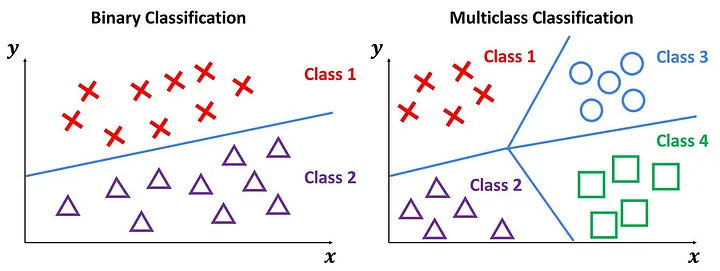

# **Multi-Class Logistic Regression**

Logistic regression naturally outputs a probability for two classes only.

So the question becomes: *How can we extend logistic regression to handle multiple classes?*

There are two common approaches:

  - **One-vs-Rest (OvR):** Train one binary classifier for each class.
  Example: Suppose we have 3 classes, Class A, Class B, Class C
  
    We train three models:
    - Model 1: A vs (B,C)
    - Model 2: B vs (A,C)
    - Model 3: C vs (A,B)

    Each classifier produces a probability.

    For a new data point, we choose the class with the highest probability.
  - **Softmax (Multinomial Logistic Regression)**

## **Softmax (Multinomial Logistic Regression)**


Instead of building several binary classifiers, we build **one model that predicts probabilities for all classes simultaneously**.

The probabilities are computed using the **Softmax function**:

$$P(y=i \mid x) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

$$z_i = \beta_{i0} + \beta_{i1}x_1 + \beta_{i2}x_2 + \dots + \beta_{in}x_n$$

Where

- $K$: number of classes  
- $z_i$: score for class \(i\)
- $ x_1, x_2, ..., x_n $: input features  
- $ \beta_{i1}, \beta_{i2}, ..., \beta_{in} $: coefficients (weights) for class $i$  
- $n$: number of features  


### **Important Property**

All probabilities **sum to 1**: $$P_1 + P_2 + ... + P_K = 1$$

### **Prediction Rule**

The predicted class is the **class with the highest probability**.


### **Key Idea**

1. Compute a **linear score \( z_i \)** for each class using the coefficients.
2. Apply the **softmax function** to convert scores into probabilities.
3. Choose the class with the **highest probability**.


**Example**

Suppose a model predicts the following probabilities for a sample:

| Class | Probability |
|------|-------------|
| Cat | 0.10 |
| Dog | 0.75 |
| Rabbit | 0.15 |

The predicted class is **Dog** because it has the highest probability.










How to perform non binary classification with Logistic Regression? Fortunately, the process with scikit-learn is pretty much the same as with binary classification. To expand our understanding, we'll go through a simple data set, as well as seeing how to use LogisiticRegression with a manual GridSearchCV (instead of LogisticRegressionCV).

## **Data**

We will work with the classic Iris Data Set. The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by the British statistician, eugenicist, and biologist Ronald Fisher in his 1936 paper The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis.

Full Details: https://en.wikipedia.org/wiki/Iris_flower_data_set

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## **Exploratory Data Analysis and Visualization**

Feel free to explore the data further on your own.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


<Axes: xlabel='species', ylabel='count'>

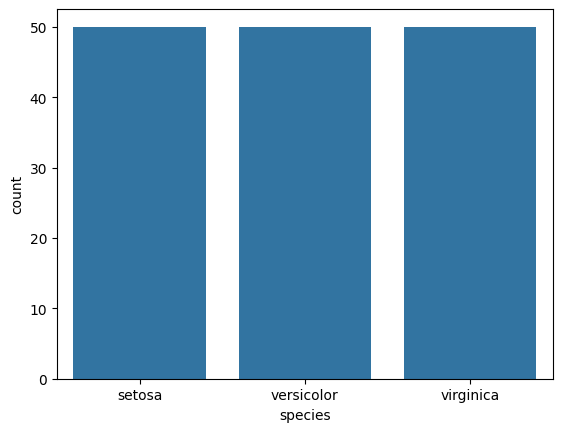

In [ ]:
sns.countplot(data=df, x='species')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

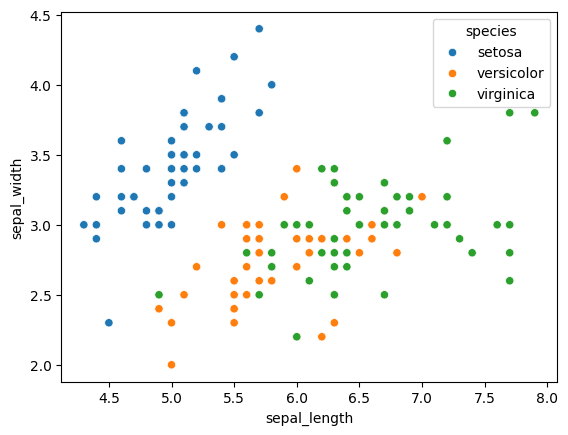

In [ ]:
sns.scatterplot(x='sepal_length',y='sepal_width',data=df,hue='species')

<Axes: xlabel='petal_length', ylabel='petal_width'>

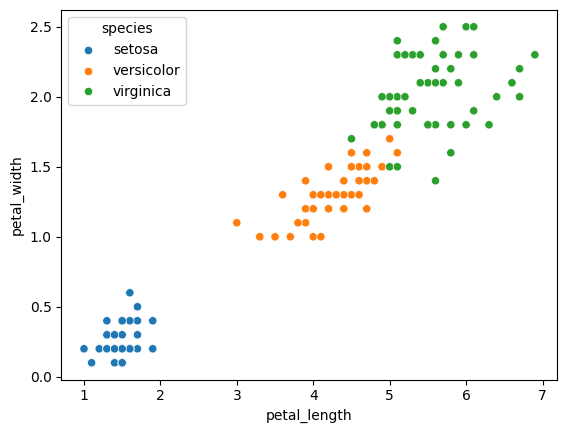

In [ ]:
sns.scatterplot(x='petal_length',y='petal_width',data=df,hue='species')

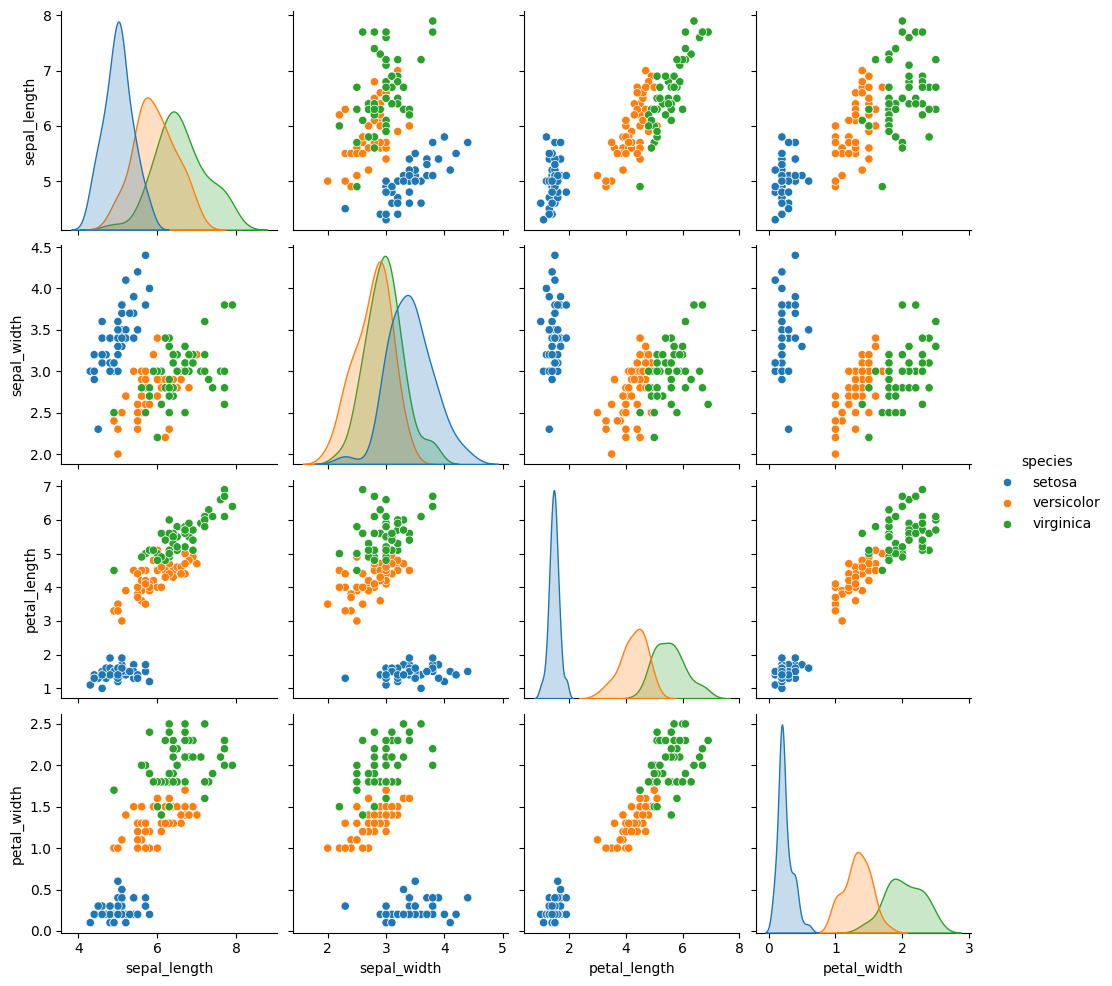

In [ ]:
sns.pairplot(df,hue='species')

<Axes: >

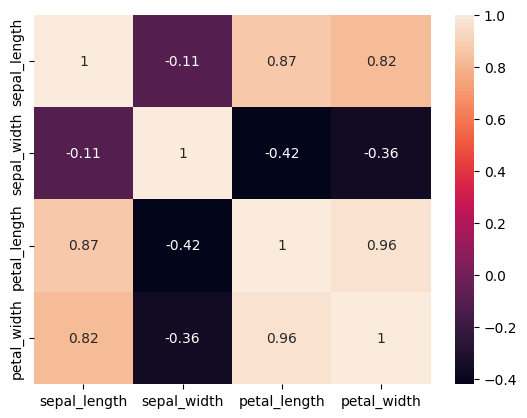

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

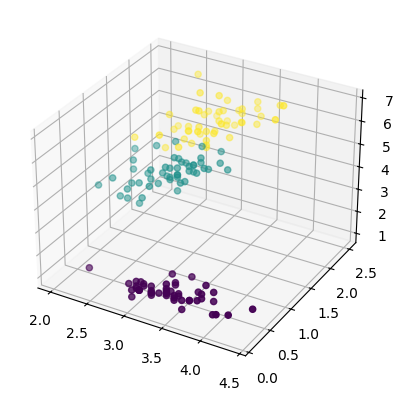

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = df['species'].map({'setosa':0, 'versicolor':1, 'virginica':2})
ax.scatter(df['sepal_width'],df['petal_width'],df['petal_length'],c=colors);

## **Train | Test Split and Scaling**

In [ ]:
X = df.drop('species',axis=1)
y = df['species']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## **Multi-Class Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Depending on warnings you may need to adjust max iterations allowed
# Or experiment with different solvers
log_model = LogisticRegression(solver='saga',multi_class="ovr",max_iter=5000)

## **GridSearch for Best Hyper-Parameters**

Main parameter choices are regularization penalty choice and regularization C value.

In [ ]:
# Penalty Type
penalty = ['l1', 'l2']

# Use logarithmically spaced C values (recommended in official docs)
C = np.logspace(0, 4, 10)

In [ ]:
grid_model = GridSearchCV(log_model,param_grid={'C':C,'penalty':penalty})

In [ ]:
grid_model.fit(scaled_X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

GridSearchCV(estimator=LogisticRegression(max_iter=5000, multi_class='ovr',
                                          solver='saga'),
             param_grid={'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2']})

In [ ]:
grid_model.best_params_

{'C': np.float64(7.742636826811269), 'penalty': 'l1'}

## **Model Performance on Classification Tasks**

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

y_pred = grid_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.9736842105263158

In [ ]:
confusion_matrix(y_test,y_pred)

array([[10,  0,  0],
       [ 0, 17,  0],
       [ 0,  1, 10]])

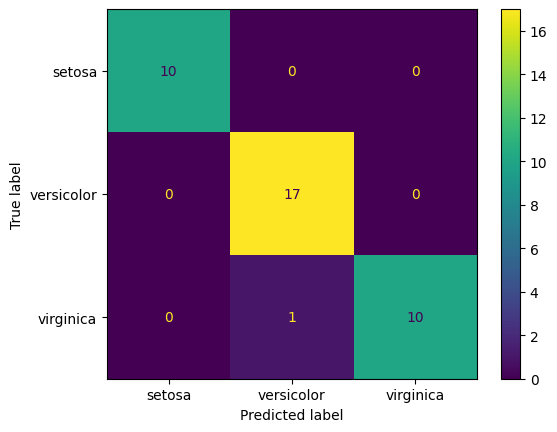

In [ ]:
cm = confusion_matrix(y_test, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_model.classes_)
display_cm.plot()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.94      1.00      0.97        17
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## **Evaluating Curves and AUC**

We need to manually create the plots for a Multi-Class situation. Fortunately, Scikit-learn's documentation already has plenty of examples on this.

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(clf, X_test, y_test, n_classes, figsize=(5,5)):
    y_score = clf.decision_function(X_test)

    # structures
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # calculate dummies once
    y_test_dummies = pd.get_dummies(y_test, drop_first=False).values
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_dummies[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # roc for each class
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic example')
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for label %i' % (roc_auc[i], i))
    ax.legend(loc="best")
    ax.grid(alpha=.4)
    sns.despine()
    plt.show()

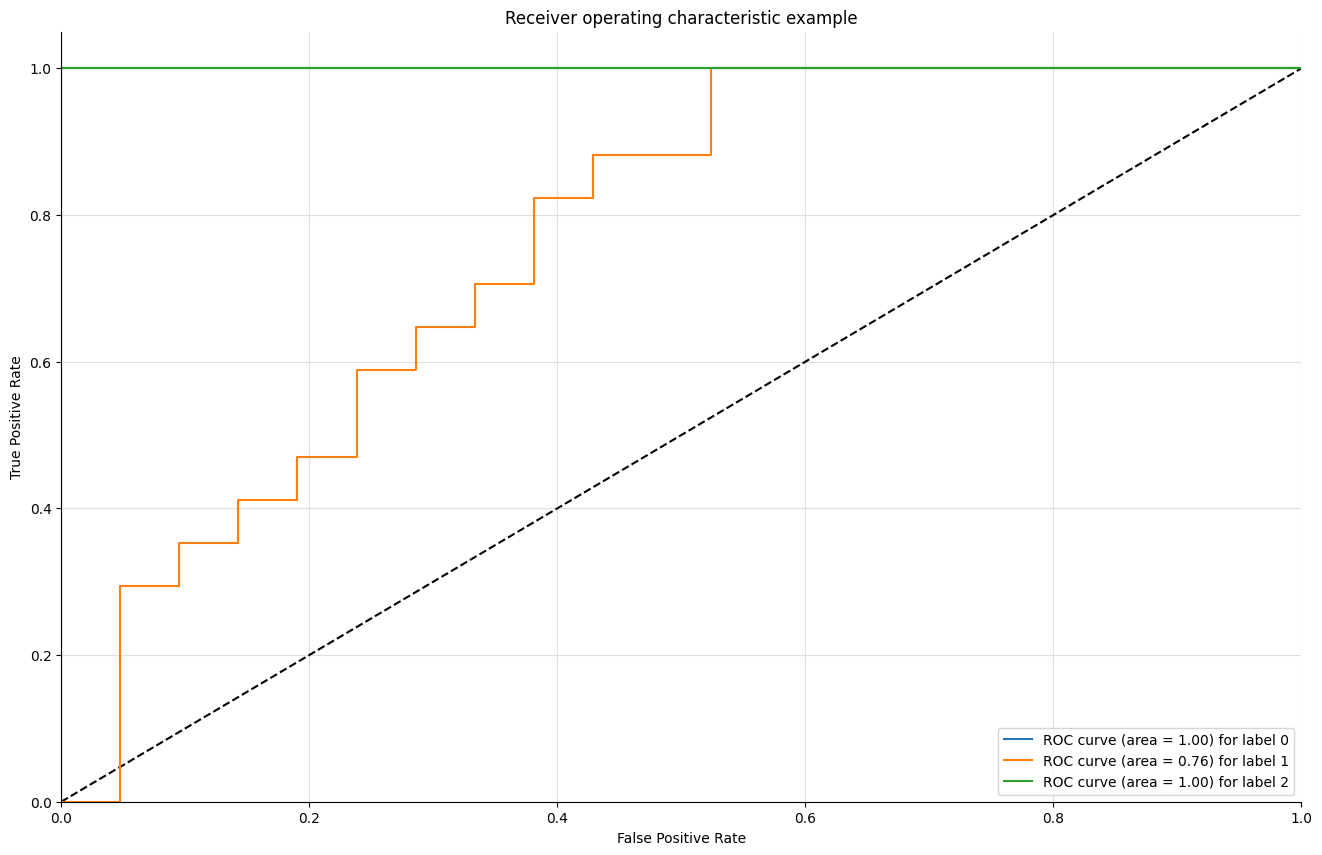

In [ ]:
plot_multiclass_roc(grid_model, scaled_X_test, y_test, n_classes=3, figsize=(16, 10))